# Identifying Latent Value Drivers with Factor Analysis

## Scenario
A meal kit customer survey captured 16 Likert-scale items (Q01–Q16) measuring
attitudes toward various aspects of meal kit services. Run exploratory factor
analysis to identify underlying customer motivation constructs and translate
them into actionable messaging guidance.

## Survey Items
- **Q01–Q04**: Recipe Quality and Variety items (e.g., "The recipe variety is an important reason I choose this meal kit")
- **Q05–Q08**: Convenience and Ease items (e.g., "I prefer meal kits that require minimal prep time")
- **Q09–Q12**: Value for Money and Budget items (e.g., "I choose meal plans primarily based on price per serving")
- **Q13–Q16**: Overall Satisfaction items (e.g., "Overall, I am satisfied with my meal kit experience") — these items cross-load across all three factors

## Data: `mealkit_survey.csv`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Exercise_Data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Exercises/Udacity Exercises Redone/')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

df = pd.read_csv(DATA_DIR / 'mealkit_survey.csv')
survey_cols = [f'Q{i:02d}' for i in range(1, 17)]
print(f"Respondents: {df.shape[0]}  |  Items: {len(survey_cols)}")
print(df[survey_cols].describe().round(2))

Respondents: 800  |  Items: 16
          Q01     Q02     Q03     Q04     Q05     Q06     Q07     Q08     Q09  \
count  800.00  800.00  800.00  800.00  800.00  800.00  800.00  800.00  800.00   
mean     3.85    4.04    3.70    3.58    3.22    3.00    3.38    2.87    2.57   
std      0.93    0.91    0.98    0.94    0.98    1.02    0.96    1.01    1.01   
min      1.00    1.00    1.00    1.00    1.00    1.00    1.00    1.00    1.00   
25%      3.00    3.00    3.00    3.00    3.00    2.00    3.00    2.00    2.00   
50%      4.00    4.00    4.00    4.00    3.00    3.00    3.00    3.00    3.00   
75%      5.00    5.00    4.00    4.00    4.00    4.00    4.00    4.00    3.00   
max      5.00    5.00    5.00    5.00    5.00    5.00    5.00    5.00    5.00   

          Q10     Q11     Q12     Q13     Q14     Q15     Q16  
count  800.00  800.00  800.00  800.00  800.00  800.00  800.00  
mean     2.32    2.49    2.42    3.32    3.16    2.94    3.08  
std      1.02    0.98    0.97    1.01    1.02  

## Step 1: Standardize Items

In [3]:
X = StandardScaler().fit_transform(df[survey_cols])
print("Standardized — each item now has mean ≈ 0 and std ≈ 1")

Standardized — each item now has mean ≈ 0 and std ≈ 1


## Step 2: Fit Factor Analysis

In [4]:
fa = FactorAnalysis(n_components=3, random_state=42)
fa.fit(X)

# Note: fa.components_ has shape (n_factors, n_items)
# We transpose to get the conventional (n_items x n_factors) loadings table
loadings = pd.DataFrame(
    fa.components_.T,
    index=survey_cols,
    columns=['Factor 1', 'Factor 2', 'Factor 3']
).round(3)
print("Loadings table (items x factors):")
print(loadings)

Loadings table (items x factors):
     Factor 1  Factor 2  Factor 3
Q01    -0.441    -0.351     0.153
Q02    -0.442    -0.459     0.152
Q03    -0.493    -0.323     0.113
Q04    -0.481    -0.448     0.127
Q05    -0.450     0.131    -0.343
Q06    -0.540     0.159    -0.457
Q07    -0.442    -0.063    -0.369
Q08    -0.417     0.162    -0.215
Q09    -0.475     0.311     0.298
Q10    -0.506     0.401     0.276
Q11    -0.437     0.371     0.295
Q12    -0.429     0.202     0.153
Q13    -0.519    -0.089    -0.019
Q14    -0.543    -0.089    -0.025
Q15    -0.572     0.090    -0.107
Q16    -0.542    -0.095    -0.001


## Step 3: Top 3 Items per Factor

In [5]:
print("Top 3 items per factor (by absolute loading value):\n")
for factor in loadings.columns:
    top3 = loadings[factor].abs().nlargest(3)
    print(f"{factor}:")
    for item in top3.index:
        val = loadings.loc[item, factor]
        sign = '+' if val > 0 else ''
        print(f"  {item}: {sign}{val:.3f}")
    print()
print("Note: Negative loadings are equally informative — high magnitude matters, not sign.")

Top 3 items per factor (by absolute loading value):

Factor 1:
  Q15: -0.572
  Q14: -0.543
  Q16: -0.542

Factor 2:
  Q02: -0.459
  Q04: -0.448
  Q10: +0.401

Factor 3:
  Q06: -0.457
  Q07: -0.369
  Q05: -0.343

Note: Negative loadings are equally informative — high magnitude matters, not sign.


## Step 4: Loadings Heatmap

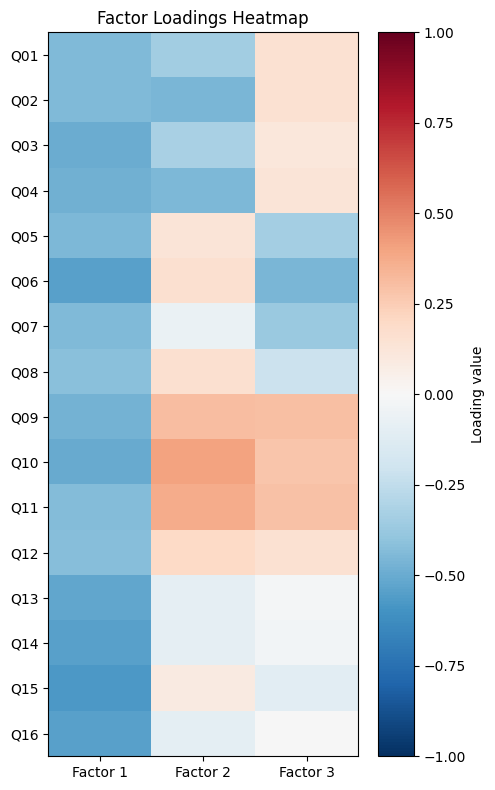

In [6]:
fig, ax = plt.subplots(figsize=(5, 8))
im = ax.imshow(loadings.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(loadings.columns)
ax.set_yticks(range(len(survey_cols))); ax.set_yticklabels(survey_cols)
plt.colorbar(im, ax=ax, label='Loading value')
ax.set_title('Factor Loadings Heatmap')
plt.tight_layout(); plt.show()

## Factor Interpretation

**Factor 1 — "General Engagement / Overall Satisfaction"**
Top items: Q15 (−0.572), Q14 (−0.543), Q16 (−0.542)
All items load in the same direction (negative) with similar magnitudes across the board. This is a **general level factor** — it captures the respondent's overall engagement with and satisfaction toward meal kit services, not a specific attitudinal dimension. Customers who score high on this factor agree broadly with all survey items; those who score low disagree broadly. The sign is an artifact of sklearn's factor orientation and does not indicate opposition.
**Messaging relevance:** This factor distinguishes highly engaged, positive customers from skeptics. Engaged customers are worth targeting for premium plan upsells and referral programs.

**Factor 2 — "Quality vs. Value Trade-off"**
Top items: Q02 (−0.459), Q04 (−0.448), Q10 (+0.401)
This is a **contrast factor**. Items Q02 and Q04 are from the Quality and Variety group (high means ~3.6–4.0), while Q10 is from the Value and Budget group (mean ~2.3). The opposite signs indicate this factor separates customers who prioritize recipe quality (strongly agree with Q02/Q04) from those who are primarily price-driven (agree with Q10). A high Factor 2 score suggests a quality-oriented customer; a low score suggests a budget-first customer.
**Messaging angle:** For high scorers — "Premium ingredients, chef-designed recipes." For low scorers — "The most meals per dollar of any plan."

**Factor 3 — "Convenience and Ease"**
Top items: Q06 (−0.457), Q07 (−0.369), Q05 (−0.343)
All three top items come from the Q05–Q08 Convenience group. This factor captures customers for whom ease of preparation and low time commitment are the primary appeal of meal kit services. The negative signs are again an artifact of sklearn's orientation — focus on the item cluster, not the sign direction.
**Messaging angle:** "Ready in 20 minutes. No meal planning required."

**Important note on labeling:** Factor labels are a human judgment based on item content. Different analysts may use different words for the same loadings pattern. Always reference specific items when presenting factor interpretations, so a reviewer can evaluate your reasoning directly.

**Note on Factor 1 all-negative loadings:** When every item loads negatively on a factor, the factor is capturing a general response tendency — overall positivity or negativity toward the survey topic. This is a real and interpretable finding, not an error. Focus on magnitude to identify which items contribute most.
